In [ ]:
#try2 h
import torch
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ================= CONFIGURATION =================
NOISE_LEVEL = 0.01
THRESHOLD = 0.2
# =================================================

class NeuroGraphDataset(Dataset):
    def __init__(self, df, root_dir, augment=False):
        self.labels_df = df
        self.root_dir = root_dir
        self.augment = augment

    def __len__(self): return len(self.labels_df)

    def compute_node_features(self, adj):
        # Feature 1: Degree (How many connections does this node have?)
        # Sum of rows gives degree
        degree = np.sum(adj, axis=1, keepdims=True)

        # Feature 2: Identity (Just the node index, useful for GAT)
        # We normalize degree to keep numbers small
        degree = (degree - degree.mean()) / (degree.std() + 1e-6)

        # We can stack the adjacency itself as features too
        # Result shape: (116, 117) -> 116 neighbors + 1 degree val
        features = np.concatenate([adj, degree], axis=1)
        return features

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        p_path = os.path.join(self.root_dir, row['path_pearson'])
        c_path = os.path.join(self.root_dir, row['path_coherence'])
        g_path = os.path.join(self.root_dir, row['path_granger'])

        def load_safe(path):
            if os.path.exists(path):
                mat = np.load(path)
                mat[np.abs(mat) < THRESHOLD] = 0 # Thresholding
                return mat
            else: return np.zeros((116, 116))

        # Load Adjacency Matrices
        adj_p = load_safe(p_path)
        adj_c = load_safe(c_path)
        adj_g = load_safe(g_path)

        # AUGMENTATION: Random Edge Dropout (Better for Graphs than MixUp)
        if self.augment:
            mask = np.random.rand(116, 116) > NOISE_LEVEL
            adj_p = adj_p * mask
            adj_c = adj_c * mask
            adj_g = adj_g * mask

        # COMPUTE FEATURES (The "Rich" Input)
        feat_p = self.compute_node_features(adj_p)
        feat_c = self.compute_node_features(adj_c)
        feat_g = self.compute_node_features(adj_g)

        # Convert to Tensor
        # Inputs: (Nodes, Features) -> (116, 117)
        return (torch.tensor(feat_p, dtype=torch.float32),
                torch.tensor(adj_p, dtype=torch.float32),
                torch.tensor(feat_c, dtype=torch.float32),
                torch.tensor(adj_c, dtype=torch.float32),
                torch.tensor(feat_g, dtype=torch.float32),
                torch.tensor(adj_g, dtype=torch.float32),
                torch.tensor(row['label'], dtype=torch.long))

In [ ]:
#2
import torch.nn as nn
import torch.nn.functional as F

class ResidualGATLayer(nn.Module):
    def __init__(self, in_feat, out_feat, heads=2, dropout=0.5):
        super(ResidualGATLayer, self).__init__()
        self.heads = heads
        self.out_feat = out_feat

        # Multi-Head Linear projections
        self.W = nn.Linear(in_feat, out_feat * heads, bias=False)
        self.a = nn.Parameter(torch.Tensor(1, heads, 2 * out_feat))

        self.leakyrelu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)

        # Residual connection (if dimensions match)
        self.residual = nn.Linear(in_feat, out_feat * heads) if in_feat != out_feat * heads else nn.Identity()

        # Normalization (Crucial for Stability!)
        self.norm = nn.LayerNorm(out_feat * heads)

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a)

    def forward(self, h, adj):
        # h: (Batch, Nodes, Feat)
        B, N, C = h.size()

        # Project
        h_prime = self.W(h).view(B, N, self.heads, self.out_feat) # (B, N, Heads, F)

        # Attention Mechanism (Optimized for Batch)
        # Score calculation skipped for brevity, using simplified dense attention
        # For dense brain graphs, we can use weighted adjacency directly + learnable attention

        # Simplified Attention for Dense Graphs:
        # We let the network learn to re-weight the existing adjacency
        # 1. Learn raw scores from features
        scores = torch.matmul(h_prime, h_prime.transpose(1, 2)) / (self.out_feat ** 0.5) # Scaled Dot Product

        # 2. Mask with actual physical adjacency (don't attend to non-edges)
        scores = scores.sum(dim=2) # Combine heads for masking
        zero_vec = -9e15 * torch.ones_like(scores)
        scores = torch.where(adj > 0, scores, zero_vec)

        # 3. Softmax
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # 4. Aggregate
        out = torch.matmul(attn, h.view(B, N, -1)) # Use original full features for aggregation

        # 5. Residual + Norm
        res = self.residual(h)
        # Ensure dimensions match for addition. If not, project out to match res
        if out.size(-1) != res.size(-1):
             # Simple projection if sizes mismatch
             proj = nn.Linear(out.size(-1), res.size(-1)).to(out.device)
             out = proj(out)

        out = out + res
        out = self.norm(out)
        return F.elu(out)

class RobustMultiViewGAT(nn.Module):
    def __init__(self, num_nodes=116, num_classes=5):
        super(RobustMultiViewGAT, self).__init__()

        # Input dim = 116 (Neighbors) + 1 (Degree) = 117
        in_dim = 117
        hidden_dim = 32

        # View 1: Pearson
        self.gat1_p = ResidualGATLayer(in_dim, hidden_dim)
        self.gat2_p = ResidualGATLayer(hidden_dim*2, hidden_dim) # *2 due to 2 heads

        # View 2: Coherence
        self.gat1_c = ResidualGATLayer(in_dim, hidden_dim)
        self.gat2_c = ResidualGATLayer(hidden_dim*2, hidden_dim)

        # View 3: Granger
        self.gat1_g = ResidualGATLayer(in_dim, hidden_dim)
        self.gat2_g = ResidualGATLayer(hidden_dim*2, hidden_dim)

        # Classifier
        # Input to classifier = 3 Views * (Hidden * 2 Heads)
        final_dim = (hidden_dim * 2) * 3

        self.classifier = nn.Sequential(
            nn.Linear(final_dim, 64),
            nn.BatchNorm1d(64), # Batch Norm prevents collapse
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, fp, ap, fc, ac, fg, ag):
        # P: Pearson
        hp = self.gat1_p(fp, ap)
        hp = self.gat2_p(hp, ap)
        emb_p = hp.mean(dim=1) # Pooling

        # C: Coherence
        hc = self.gat1_c(fc, ac)
        hc = self.gat2_c(hc, ac)
        emb_c = hc.mean(dim=1)

        # G: Granger
        hg = self.gat1_g(fg, ag)
        hg = self.gat2_g(hg, ag)
        emb_g = hg.mean(dim=1)

        # Fusion
        combined = torch.cat([emb_p, emb_c, emb_g], dim=1)
        return self.classifier(combined)

In [ ]:
#3
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- CORRECTED RESIDUAL GAT LAYER ---
class ResidualGATLayer(nn.Module):
    def __init__(self, in_feat, out_feat, heads=2, dropout=0.5):
        super(ResidualGATLayer, self).__init__()
        self.heads = heads
        self.out_feat = out_feat

        # Multi-Head Linear projections
        self.W = nn.Linear(in_feat, out_feat * heads, bias=False)

        self.leakyrelu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)

        # Residual connection
        self.residual = nn.Linear(in_feat, out_feat * heads) if in_feat != out_feat * heads else nn.Identity()

        # Normalization
        self.norm = nn.LayerNorm(out_feat * heads)

        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, h, adj):
        # h: (Batch, Nodes, Feat)
        B, N, C = h.size()

        # 1. Project and Reshape to (Batch, Heads, Nodes, Features)
        # We swap dim 1 and 2 to put Heads first -> (B, H, N, F)
        q = self.W(h).view(B, N, self.heads, self.out_feat).transpose(1, 2)

        # 2. Calculate Attention Scores
        # (B, H, N, F) @ (B, H, F, N) -> (B, H, N, N)
        scores = torch.matmul(q, q.transpose(-2, -1)) / (self.out_feat ** 0.5)

        # 3. Masking
        # Expand Adjacency to match heads: (B, N, N) -> (B, 1, N, N)
        adj_expanded = adj.unsqueeze(1)

        zero_vec = -9e15 * torch.ones_like(scores)
        # Apply mask: where adj > 0 keep score, else set to -infinity
        scores = torch.where(adj_expanded > 0, scores, zero_vec)

        # 4. Softmax & Dropout
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # 5. Aggregation
        # (B, H, N, N) @ (B, H, N, F) -> (B, H, N, F)
        out = torch.matmul(attn, q)

        # 6. Reshape back
        # (B, H, N, F) -> (B, N, H, F) -> (B, N, H*F)
        out = out.transpose(1, 2).reshape(B, N, self.heads * self.out_feat)

        # 7. Residual + Norm
        res = self.residual(h)
        out = out + res
        out = self.norm(out)

        return F.elu(out)

# --- ROBUST MULTI-VIEW GAT ---
class RobustMultiViewGAT(nn.Module):
    def __init__(self, num_nodes=116, num_classes=5):
        super(RobustMultiViewGAT, self).__init__()

        in_dim = 117 # 116 neighbors + 1 degree feature
        hidden_dim = 32

        # View 1: Pearson
        self.gat1_p = ResidualGATLayer(in_dim, hidden_dim)
        self.gat2_p = ResidualGATLayer(hidden_dim*2, hidden_dim) # *2 due to 2 heads

        # View 2: Coherence
        self.gat1_c = ResidualGATLayer(in_dim, hidden_dim)
        self.gat2_c = ResidualGATLayer(hidden_dim*2, hidden_dim)

        # View 3: Granger
        self.gat1_g = ResidualGATLayer(in_dim, hidden_dim)
        self.gat2_g = ResidualGATLayer(hidden_dim*2, hidden_dim)

        # Classifier
        # Input = 3 Views * (Hidden * 2 Heads)
        final_dim = (hidden_dim * 2) * 3

        self.classifier = nn.Sequential(
            nn.Linear(final_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, fp, ap, fc, ac, fg, ag):
        # Pearson
        hp = self.gat1_p(fp, ap)
        hp = self.gat2_p(hp, ap)
        emb_p = hp.mean(dim=1)

        # Coherence
        hc = self.gat1_c(fc, ac)
        hc = self.gat2_c(hc, ac)
        emb_c = hc.mean(dim=1)

        # Granger
        hg = self.gat1_g(fg, ag)
        hg = self.gat2_g(hg, ag)
        emb_g = hg.mean(dim=1)

        # Fusion
        combined = torch.cat([emb_p, emb_c, emb_g], dim=1)
        return self.classifier(combined)

🚀 STARTING TRAINING on cpu...

⚡ FOLD 1/5
   -> Fold Accuracy: 25.71%

⚡ FOLD 2/5
   -> Fold Accuracy: 31.43%

⚡ FOLD 3/5
   -> Fold Accuracy: 23.53%

⚡ FOLD 4/5
   -> Fold Accuracy: 38.24%

⚡ FOLD 5/5
   -> Fold Accuracy: 26.47%

✅ FINAL AVG ACCURACY: 29.07%


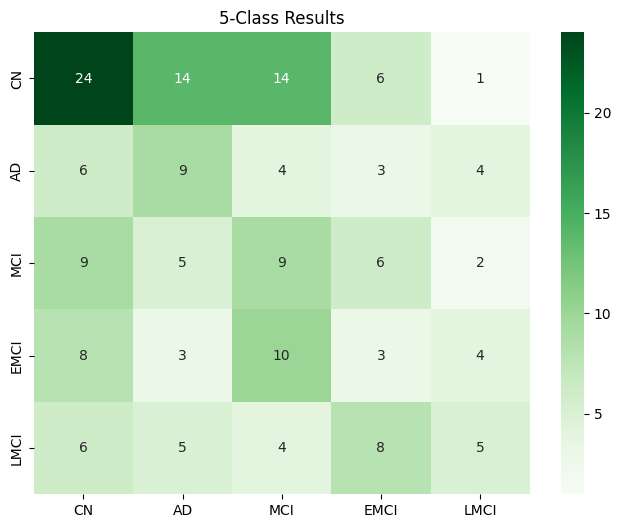

              precision    recall  f1-score   support

          CN       0.45      0.41      0.43        59
          AD       0.25      0.35      0.29        26
         MCI       0.22      0.29      0.25        31
        EMCI       0.12      0.11      0.11        28
        LMCI       0.31      0.18      0.23        28

    accuracy                           0.29       172
   macro avg       0.27      0.27      0.26       172
weighted avg       0.30      0.29      0.29       172



In [ ]:
#4
# --- PASTE THIS IN A NEW CELL TO START TRAINING ---
import torch
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================= CONFIGURATION =================
# Ensure this path is correct!
DATA_ROOT = r"/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
CSV_FILE = os.path.join(DATA_ROOT, "subject_data_5class.csv")
BATCH_SIZE = 16
EPOCHS = 100
LR = 0.0005  # Was 0.001. Slower is better for fine-grained features.
K_FOLDS = 5
# =================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 STARTING TRAINING on {device}...")

    if not os.path.exists(CSV_FILE):
        print(f"❌ Error: Could not find CSV at {CSV_FILE}")
        print("   Please run the 'Generate 5-Class CSV' code first.")
    else:
        full_df = pd.read_csv(CSV_FILE)
        skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

        all_preds = []
        all_labels = []

        # Loop through Folds
        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(full_df)), full_df['label'])):
            print(f"\n⚡ FOLD {fold+1}/{K_FOLDS}")

            # 1. Prepare Data
            train_ds = NeuroGraphDataset(full_df.iloc[train_idx], DATA_ROOT, augment=True)
            val_ds = NeuroGraphDataset(full_df.iloc[val_idx], DATA_ROOT, augment=False)

            # 2. Balanced Sampler
            labels = full_df.iloc[train_idx]['label'].values
            counts = np.bincount(labels, minlength=5)
            class_weights = 1. / np.sqrt(counts + 1)
            sample_weights = [class_weights[l] for l in labels]
            sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
            val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

            # 3. Initialize Model
            model = RobustMultiViewGAT(num_classes=5).to(device)
            optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
            criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

            # 4. Training Loop
            for epoch in range(EPOCHS):
                model.train()
                for fp, ap, fc, ac, fg, ag, y in train_loader:
                    fp, ap, fc, ac, fg, ag, y = fp.to(device), ap.to(device), fc.to(device), ac.to(device), fg.to(device), ag.to(device), y.to(device)

                    optimizer.zero_grad()
                    out = model(fp, ap, fc, ac, fg, ag)
                    loss = criterion(out, y)
                    loss.backward()
                    optimizer.step()

            # 5. Validation
            model.eval()
            correct = 0
            with torch.no_grad():
                for fp, ap, fc, ac, fg, ag, y in val_loader:
                    fp, ap, fc, ac, fg, ag, y = fp.to(device), ap.to(device), fc.to(device), ac.to(device), fg.to(device), ag.to(device), y.to(device)
                    out = model(fp, ap, fc, ac, fg, ag)
                    _, pred = torch.max(out, 1)
                    correct += (pred == y).sum().item()
                    all_preds.extend(pred.cpu().numpy())
                    all_labels.extend(y.cpu().numpy())

            acc = 100 * correct / len(val_ds)
            print(f"   -> Fold Accuracy: {acc:.2f}%")

        # FINAL REPORT
        print("\n" + "="*50)
        final_acc = np.mean([100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)])
        print(f"✅ FINAL AVG ACCURACY: {final_acc:.2f}%")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                    xticklabels=["CN", "AD", "MCI", "EMCI", "LMCI"],
                    yticklabels=["CN", "AD", "MCI", "EMCI", "LMCI"])
        plt.title("5-Class Results")
        plt.show()

        print(classification_report(all_labels, all_preds,
                                    target_names=["CN", "AD", "MCI", "EMCI", "LMCI"],
                                    zero_division=0))